# Geographical EDA — Break Comparison
**deliverable:** Validate domain knowledge by comparing how the three SD breaks respond differently to the same swell conditions.

**Core question:** Does the data confirm that Blacks/PB Point favour west swells while La Jolla Shores favours south swells?

**Sections:**
1. Break + buoy map
2. Swell direction distribution
3. Swell direction scoring per break
4. West vs south swell — do the breaks diverge?
5. Wind offshore analysis per break
6. Tide window analysis per break
7. Summary findings

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Wedge
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from etl.fetch_buoy import fetch_buoy_swell
from etl.fetch_wind import fetch_wind_all_breaks
from etl.fetch_tide import fetch_tide_heights

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# --- Domain constants from domain.pdf ---
BREAKS = {
    'blacks':          {'lat': 32.8807, 'lon': -117.2436, 'color': '#e74c3c',
                        'optimal_mwd': 285, 'mwd_range': (270, 300),
                        'offshore_wind': 90,  'tide_range_ft': (0.5, 3.5)},
    'la_jolla_shores': {'lat': 32.8579, 'lon': -117.2575, 'color': '#3498db',
                        'optimal_mwd': 200, 'mwd_range': (180, 220),
                        'offshore_wind': 20,  'tide_range_ft': (2.5, 5.0)},
    'pb_point':        {'lat': 32.7970, 'lon': -117.2550, 'color': '#2ecc71',
                        'optimal_mwd': 290, 'mwd_range': (270, 310),
                        'offshore_wind': 110, 'tide_range_ft': (1.0, 3.5)},
}

BUOYS = {
    '46232': {'lat': 32.548, 'lon': -117.424, 'name': 'Point Loma South'},
    '46254': {'lat': 32.748, 'lon': -117.367, 'name': 'Mission Bay West'},
}

FT_PER_M = 3.28084

print("Imports OK")

Imports OK


In [2]:
buoy = fetch_buoy_swell(days=30, use_cache=True)
wind = fetch_wind_all_breaks()
tide = fetch_tide_heights(days=30)

print(f"Buoy rows : {len(buoy)}  |  stations: {buoy['station'].unique()}")
print(f"Wind rows : {len(wind)}  |  breaks: {wind['break_id'].unique()}")
print(f"Tide rows : {len(tide)}")
buoy.head(3)

forecastHourly 404 for blacks — skipping


Buoy rows : 455  |  stations: ['46232' '46254']
Wind rows : 312  |  breaks: ['la_jolla_shores' 'pb_point']
Tide rows : 722


,timestamp_utc,station,WVHT,DPD,MWD,APD
0,2026-04-28 22:56:00+00:00,46232,1.0,17.0,178.0,5.1
1,2026-04-28 22:26:00+00:00,46232,1.0,12.0,249.0,5.4
2,2026-04-28 21:56:00+00:00,46232,0.9,12.0,259.0,5.6


## 1 — Break + Buoy Map
Where are the breaks relative to the buoys? Understanding proximity helps explain why both buoys serve all three breaks.

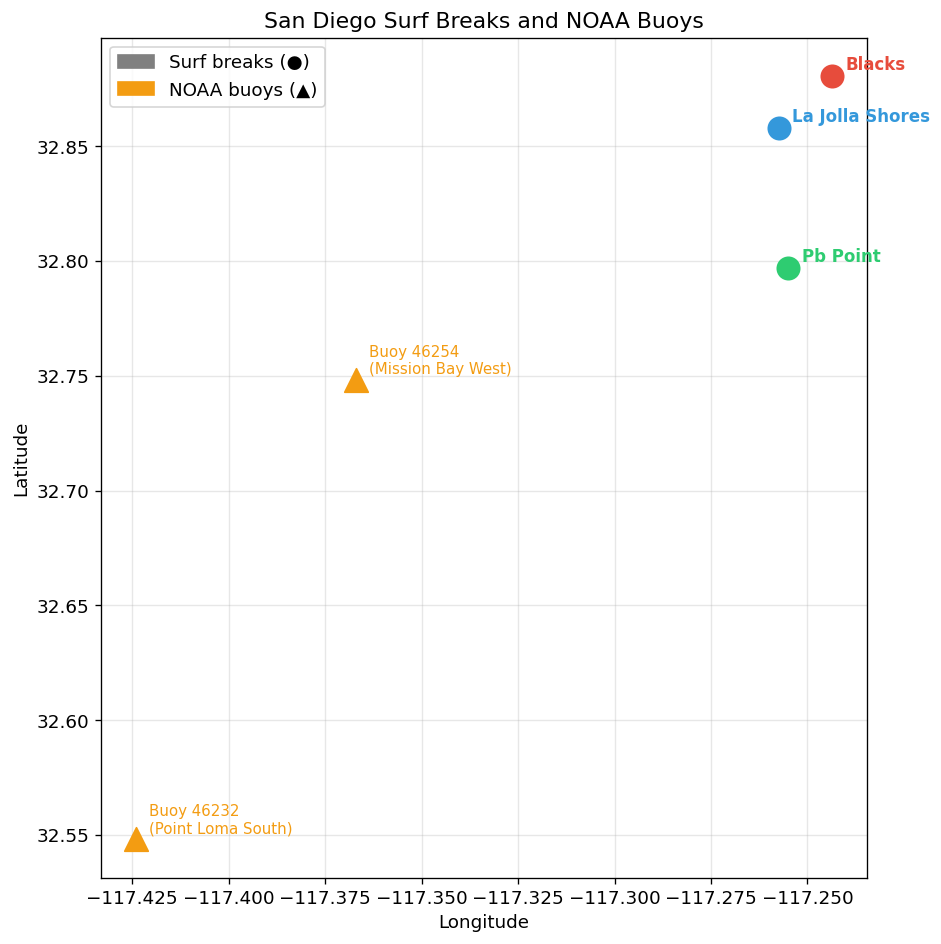

In [3]:
fig, ax = plt.subplots(figsize=(8, 8))

for name, b in BREAKS.items():
    ax.scatter(b['lon'], b['lat'], s=180, color=b['color'], zorder=5, marker='o')
    ax.annotate(name.replace('_', ' ').title(),
                (b['lon'], b['lat']), textcoords='offset points',
                xytext=(8, 4), fontsize=10, color=b['color'], fontweight='bold')

for sid, b in BUOYS.items():
    ax.scatter(b['lon'], b['lat'], s=200, color='#f39c12', zorder=5, marker='^')
    ax.annotate(f"Buoy {sid}\n({b['name']})",
                (b['lon'], b['lat']), textcoords='offset points',
                xytext=(8, 4), fontsize=9, color='#f39c12')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('San Diego Surf Breaks and NOAA Buoys')
ax.grid(True, alpha=0.3)

break_patch = mpatches.Patch(color='gray', label='Surf breaks (●)')
buoy_patch  = mpatches.Patch(color='#f39c12', label='NOAA buoys (▲)')
ax.legend(handles=[break_patch, buoy_patch])

plt.tight_layout()
plt.show()

## 2 — Swell Direction Distribution
A polar histogram (rose plot) of MWD — which directions does SD swell most commonly arrive from? Each break's optimal window is overlaid as a shaded arc.

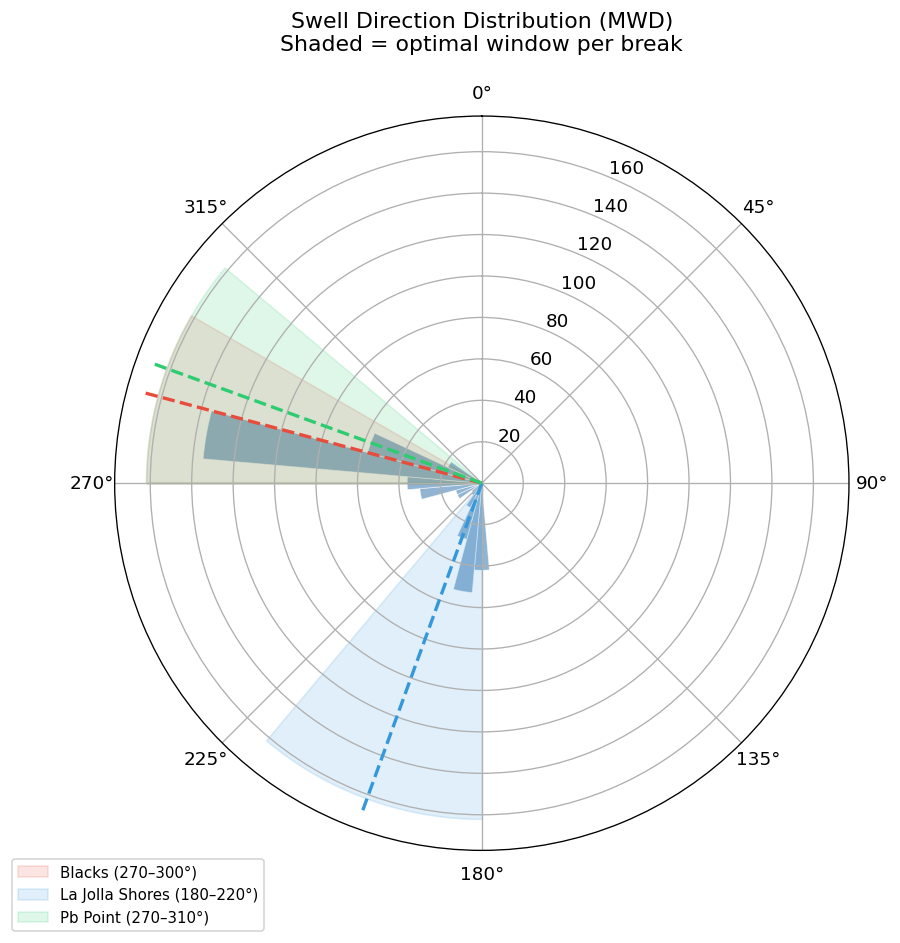


MWD stats over 30 days:
count    455.0
mean     253.3
std       41.9
min      170.0
25%      205.5
50%      277.0
75%      287.0
max      309.0
Name: MWD, dtype: float64


In [4]:
mwd = buoy['MWD'].dropna()

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='polar'))

# Polar histogram — MWD is compass bearing so we convert to math angles
n_bins = 36
bin_edges = np.linspace(0, 360, n_bins + 1)
counts, _ = np.histogram(mwd, bins=bin_edges)
theta = np.deg2rad(bin_edges[:-1])   # left edge of each bin
width = np.deg2rad(360 / n_bins)

# Polar bar: compass 0°=North, clockwise — so offset by 90° and flip
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
bars = ax.bar(theta, counts, width=width, bottom=0, alpha=0.6,
              color='steelblue', edgecolor='white', linewidth=0.5)

# Overlay each break's optimal MWD window
for name, b in BREAKS.items():
    lo = np.deg2rad(b['mwd_range'][0])
    hi = np.deg2rad(b['mwd_range'][1])
    span = np.linspace(lo, hi, 50)
    ax.fill_between(span, 0, counts.max() * 1.2, alpha=0.15,
                    color=b['color'], label=f"{name.replace('_',' ').title()} ({b['mwd_range'][0]}–{b['mwd_range'][1]}°)")
    ax.plot([np.deg2rad(b['optimal_mwd'])] * 2, [0, counts.max() * 1.25],
            color=b['color'], linewidth=2, linestyle='--')

ax.set_title('Swell Direction Distribution (MWD)\nShaded = optimal window per break', pad=20)
ax.legend(loc='lower left', bbox_to_anchor=(-0.15, -0.12), fontsize=9)
plt.tight_layout()
plt.show()

print(f"\nMWD stats over 30 days:")
print(mwd.describe().round(1))

## 3 — Swell Direction Score Per Break
For every hour of buoy data, compute how well the swell direction aligns with each break's optimal window. Score = 1.0 means perfect alignment, 0.0 means the worst possible direction.

Formula: `score = 1 - angular_distance(MWD, optimal) / 180`

This is the core domain validation — we expect Blacks and PB Point to score similarly (both like west), while La Jolla scores differently.

In [5]:
def angular_distance(a, b):
    """Smallest angle between two compass bearings (0–180)."""
    diff = np.abs(a - b) % 360
    return np.where(diff > 180, 360 - diff, diff)

def swell_dir_score(mwd_series, optimal_deg):
    dist = angular_distance(mwd_series, optimal_deg)
    return 1 - dist / 180

df = buoy[['timestamp_utc', 'station', 'MWD', 'WVHT', 'DPD', 'APD']].dropna(subset=['MWD']).copy()

for name, b in BREAKS.items():
    df[f'dir_score_{name}'] = swell_dir_score(df['MWD'], b['optimal_mwd'])

score_cols = [f'dir_score_{n}' for n in BREAKS]
print("Mean direction score per break (30 days):")
print(df[score_cols].mean().round(3).rename(lambda c: c.replace('dir_score_', '')))
df[score_cols].head()

Mean direction score per break (30 days):
blacks             0.800
la_jolla_shores    0.678
pb_point           0.785
dtype: float64


,dir_score_blacks,dir_score_la_jolla_shores,dir_score_pb_point
0,0.405556,0.877778,0.377778
1,0.800000,0.727778,0.772222
2,0.855556,0.672222,0.827778
3,0.838889,0.688889,0.811111
4,0.977778,0.550000,0.950000


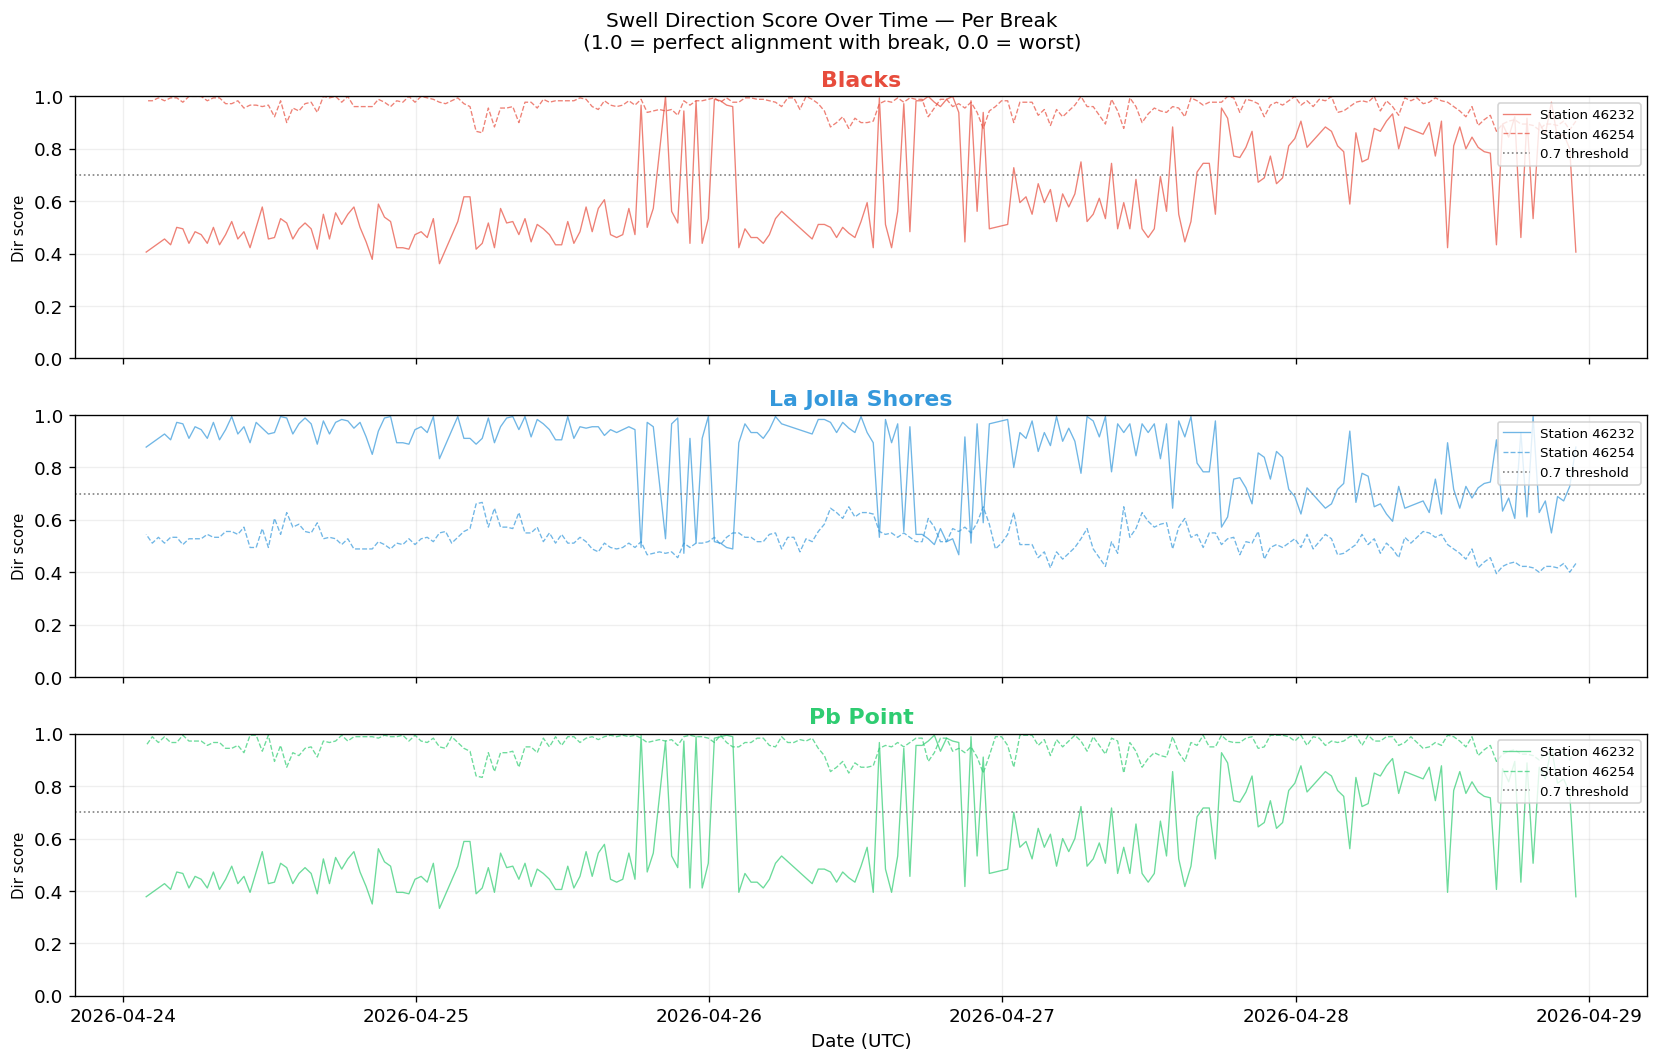

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

colors = [BREAKS[n]['color'] for n in BREAKS]
labels = [n.replace('_', ' ').title() for n in BREAKS]

for ax, name, color, label in zip(axes, BREAKS, colors, labels):
    col = f'dir_score_{name}'
    for station, grp in df.groupby('station'):
        ax.plot(grp['timestamp_utc'], grp[col], alpha=0.7,
                linewidth=0.8, label=f'Station {station}', color=color,
                linestyle='-' if station == '46232' else '--')
    ax.axhline(0.7, color='gray', linestyle=':', linewidth=1, label='0.7 threshold')
    ax.set_ylabel('Dir score', fontsize=9)
    ax.set_title(label, color=color, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.2)

axes[-1].set_xlabel('Date (UTC)')
fig.suptitle('Swell Direction Score Over Time — Per Break\n(1.0 = perfect alignment with break, 0.0 = worst)', fontsize=12)
plt.tight_layout()
plt.show()

## 4 — West vs South Swell: Do the Breaks Diverge?
**The key validation.** Filter hours into west swell (270–300°) and south swell (180–220°) windows. If domain knowledge is correct:
- West swell → Blacks and PB Point score high, La Jolla scores low
- South swell → La Jolla scores high, Blacks and PB Point score low

West swell hours  (270–300°): 228
South swell hours (180–220°): 136


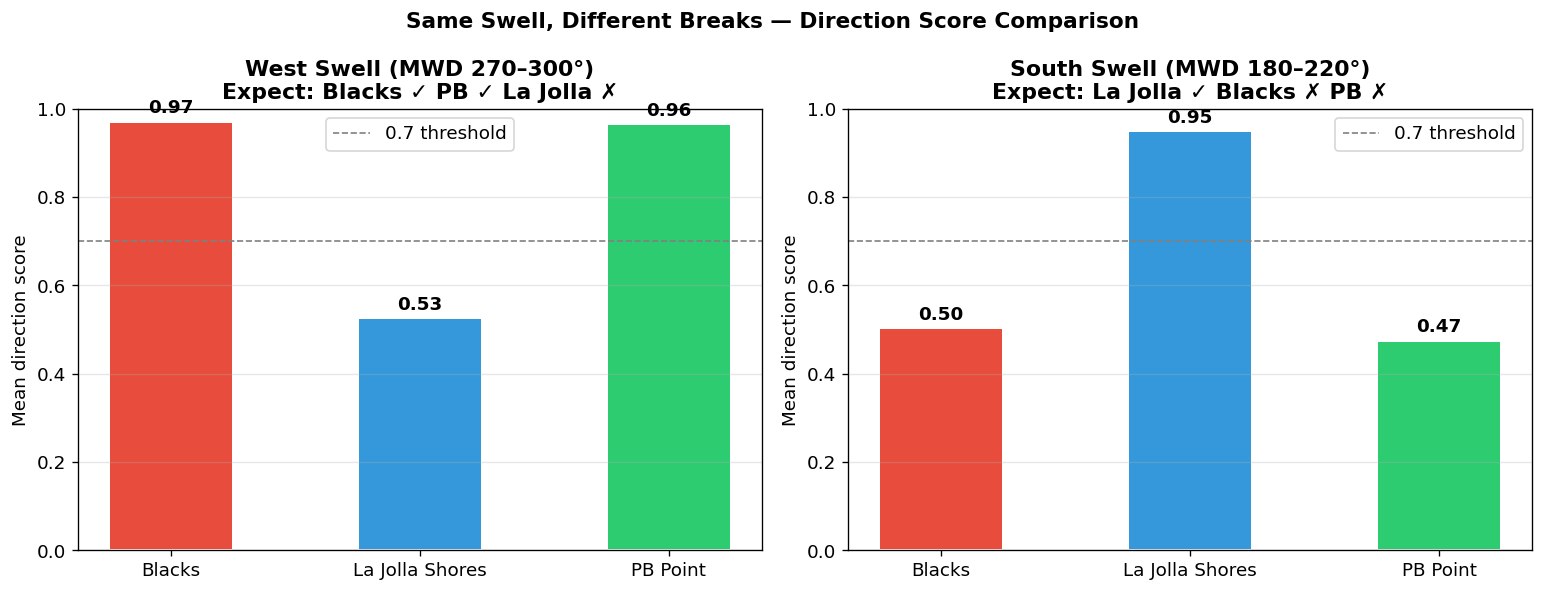

In [7]:
west_swell  = df[(df['MWD'] >= 270) & (df['MWD'] <= 300)]
south_swell = df[(df['MWD'] >= 180) & (df['MWD'] <= 220)]

print(f"West swell hours  (270–300°): {len(west_swell)}")
print(f"South swell hours (180–220°): {len(south_swell)}")

break_labels = ['Blacks', 'La Jolla Shores', 'PB Point']
break_keys   = list(BREAKS.keys())
colors_list  = [BREAKS[k]['color'] for k in break_keys]

west_means  = [west_swell[f'dir_score_{k}'].mean()  for k in break_keys]
south_means = [south_swell[f'dir_score_{k}'].mean() for k in break_keys]

x = np.arange(len(break_labels))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# West swell
bars1 = axes[0].bar(x, west_means, width=0.5, color=colors_list, edgecolor='white', linewidth=1.2)
axes[0].set_title('West Swell (MWD 270–300°)\nExpect: Blacks ✓ PB ✓ La Jolla ✗', fontweight='bold')
axes[0].set_xticks(x); axes[0].set_xticklabels(break_labels)
axes[0].set_ylabel('Mean direction score')
axes[0].set_ylim(0, 1)
axes[0].axhline(0.7, color='gray', linestyle='--', linewidth=1, label='0.7 threshold')
for bar, val in zip(bars1, west_means):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.2f}',
                 ha='center', fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# South swell
bars2 = axes[1].bar(x, south_means, width=0.5, color=colors_list, edgecolor='white', linewidth=1.2)
axes[1].set_title('South Swell (MWD 180–220°)\nExpect: La Jolla ✓ Blacks ✗ PB ✗', fontweight='bold')
axes[1].set_xticks(x); axes[1].set_xticklabels(break_labels)
axes[1].set_ylabel('Mean direction score')
axes[1].set_ylim(0, 1)
axes[1].axhline(0.7, color='gray', linestyle='--', linewidth=1, label='0.7 threshold')
for bar, val in zip(bars2, south_means):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.2f}',
                 ha='center', fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

fig.suptitle('Same Swell, Different Breaks — Direction Score Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5 — Which Break is Favoured Each Hour?
For each hour, which break has the highest swell direction score? Shows how often each break "wins" over the 30-day window.

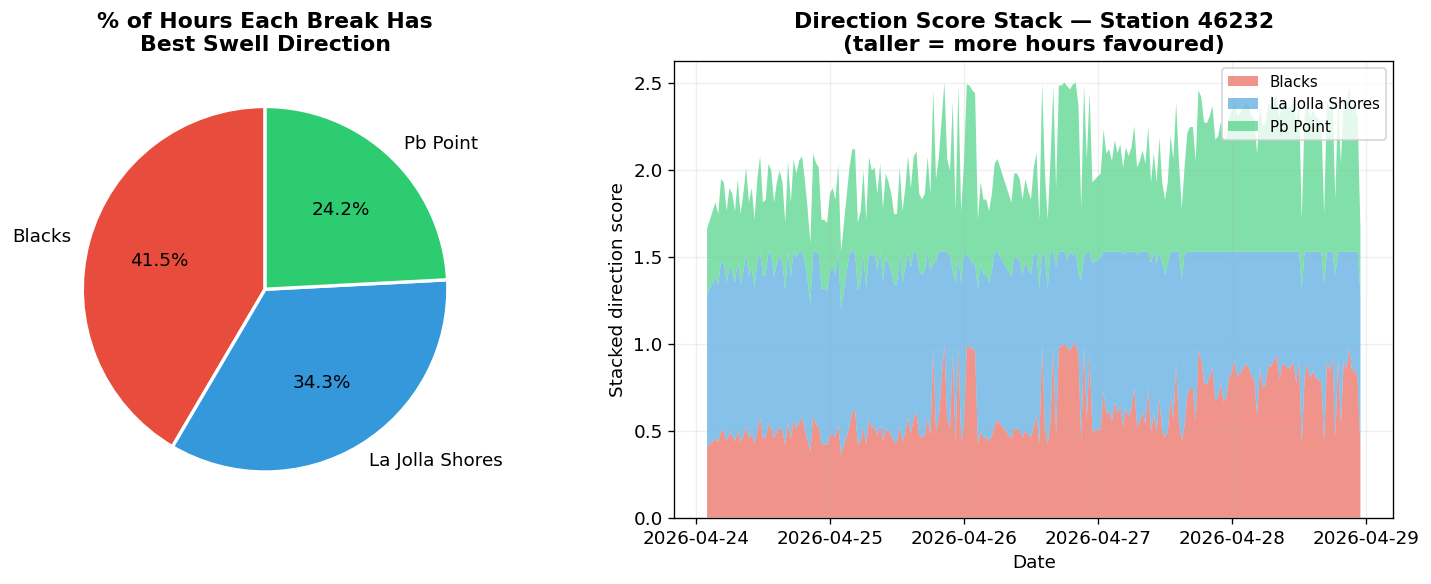


Hours each break is favoured:
best_break
Blacks             189
La Jolla Shores    156
Pb Point           110
Name: count, dtype: int64


In [8]:
df['best_break'] = df[score_cols].idxmax(axis=1).str.replace('dir_score_', '')

counts = df['best_break'].value_counts()
pie_colors = [BREAKS[k]['color'] for k in counts.index]
pie_labels = [k.replace('_', ' ').title() for k in counts.index]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].pie(counts.values, labels=pie_labels, colors=pie_colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('% of Hours Each Break Has\nBest Swell Direction', fontweight='bold')

# Stacked area — score over time for all three (use one station for clarity)
df_one = df[df['station'] == '46232'].sort_values('timestamp_utc')
axes[1].stackplot(df_one['timestamp_utc'],
                  [df_one[f'dir_score_{k}'] for k in BREAKS],
                  labels=pie_labels, colors=colors_list, alpha=0.6)
axes[1].set_title('Direction Score Stack — Station 46232\n(taller = more hours favoured)', fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Stacked direction score')
axes[1].legend(loc='upper right', fontsize=9)
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

print("\nHours each break is favoured:")
print(counts.rename(index=lambda x: x.replace('_', ' ').title()))

## 6 — Wind Offshore Score Per Break
Using NWS forecast wind data — how offshore is the wind at each break? Offshore score = 1.0 means wind is blowing perfectly offshore, 0.0 means perfectly onshore.

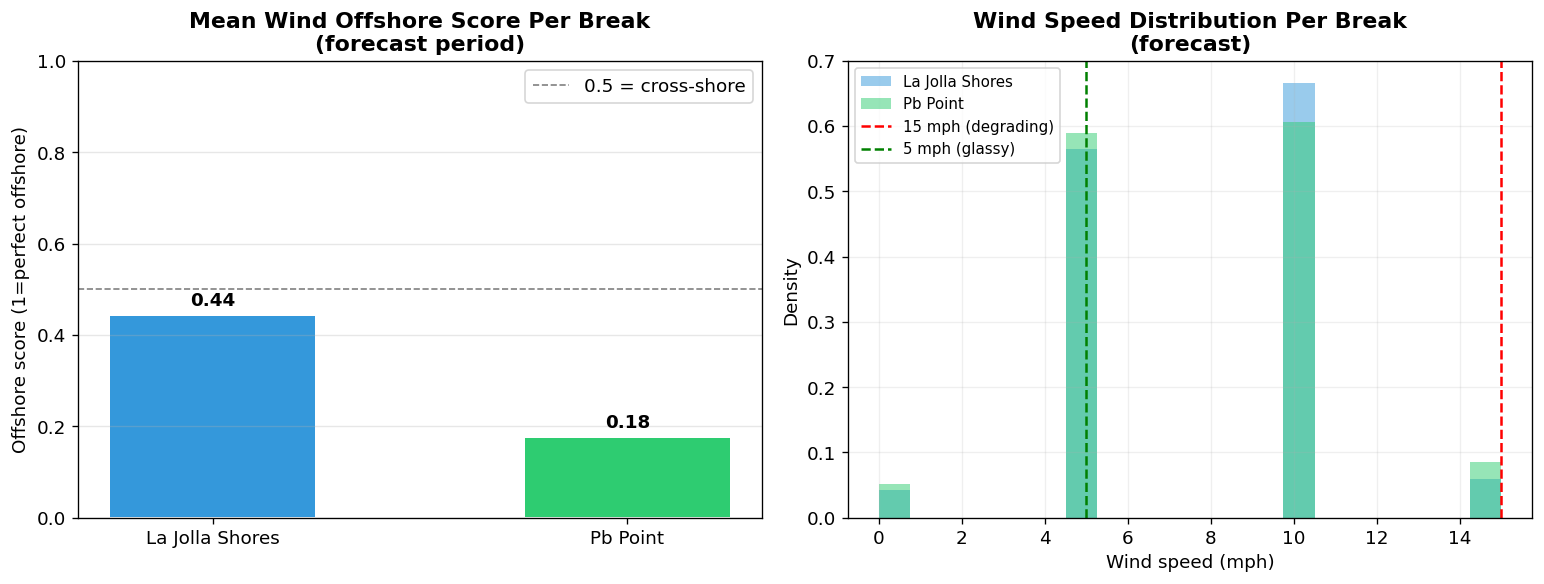

In [9]:
def offshore_score(wind_dir_series, offshore_deg):
    """1.0 = perfectly offshore, 0.0 = perfectly onshore."""
    dist = angular_distance(wind_dir_series, offshore_deg)
    return 1 - dist / 180

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Per-break mean offshore score
mean_offshore = {}
for name, b in BREAKS.items():
    grp = wind[wind['break_id'] == name].copy()
    if grp.empty:
        mean_offshore[name] = np.nan
        continue
    grp['offshore_score'] = offshore_score(grp['wind_direction_degrees'], b['offshore_wind'])
    mean_offshore[name] = grp['offshore_score'].mean()

bar_colors = [BREAKS[k]['color'] for k in BREAKS]
bar_labels = [k.replace('_', ' ').title() for k in BREAKS]
bars = axes[0].bar(bar_labels, mean_offshore.values(), color=bar_colors,
                   edgecolor='white', linewidth=1.2, width=0.5)
axes[0].set_title('Mean Wind Offshore Score Per Break\n(forecast period)', fontweight='bold')
axes[0].set_ylabel('Offshore score (1=perfect offshore)')
axes[0].set_ylim(0, 1)
axes[0].axhline(0.5, color='gray', linestyle='--', linewidth=1, label='0.5 = cross-shore')
for bar, val in zip(bars, mean_offshore.values()):
    if not np.isnan(val):
        axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.02,
                     f'{val:.2f}', ha='center', fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Wind speed distribution per break
for name, b in BREAKS.items():
    grp = wind[wind['break_id'] == name]
    if not grp.empty:
        axes[1].hist(grp['wind_speed_mph'], bins=20, alpha=0.5,
                     color=b['color'], label=name.replace('_', ' ').title(), density=True)

axes[1].axvline(15, color='red', linestyle='--', linewidth=1.5, label='15 mph (degrading)')
axes[1].axvline(5,  color='green', linestyle='--', linewidth=1.5, label='5 mph (glassy)')
axes[1].set_title('Wind Speed Distribution Per Break\n(forecast)', fontweight='bold')
axes[1].set_xlabel('Wind speed (mph)')
axes[1].set_ylabel('Density')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 7 — Tide Window Analysis Per Break
What percentage of historical hours fall within each break's preferred tide window? Converts metres to feet for comparison with domain guide thresholds.

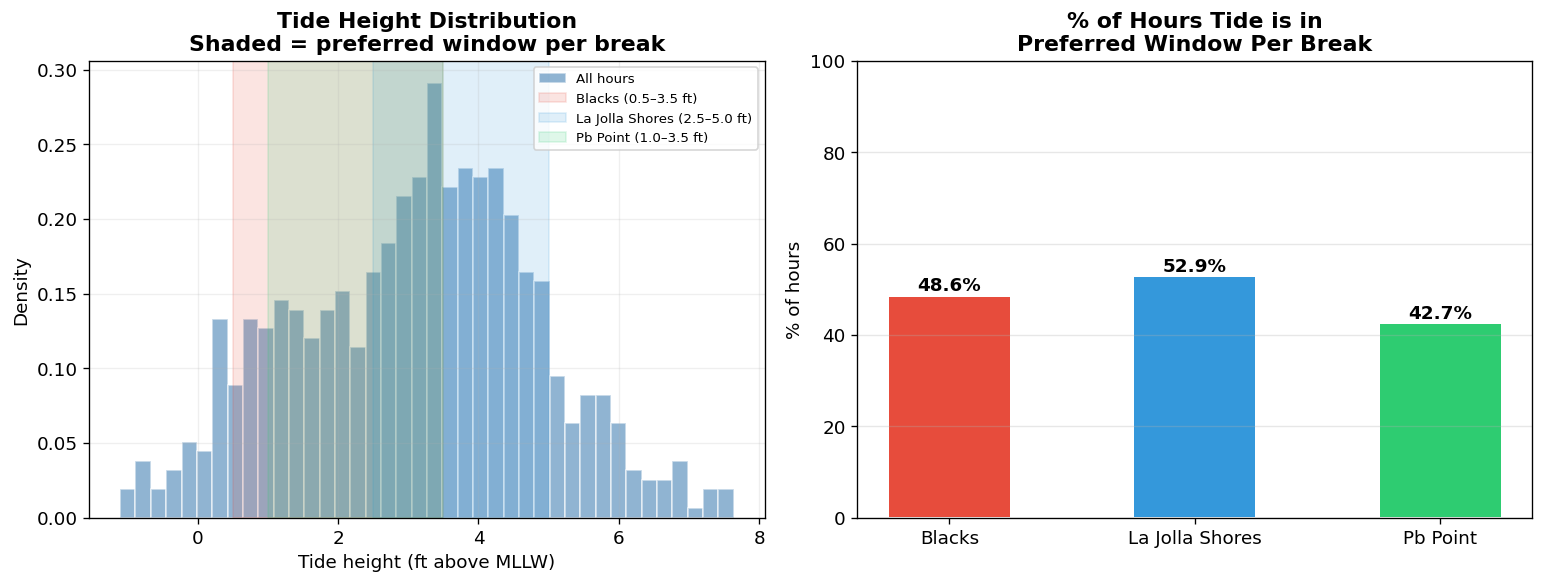


Tide stats (feet):
count    722.00
mean       3.10
std        1.73
min       -1.11
25%        1.83
50%        3.27
75%        4.30
max        7.64
Name: tide_height_ft, dtype: float64


In [10]:
tide_ft = tide.copy()
tide_ft['tide_height_ft'] = tide_ft['tide_height_m'] * FT_PER_M

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Tide height distribution with preferred windows shaded
axes[0].hist(tide_ft['tide_height_ft'], bins=40, color='steelblue',
             alpha=0.6, edgecolor='white', density=True, label='All hours')
for name, b in BREAKS.items():
    lo, hi = b['tide_range_ft']
    axes[0].axvspan(lo, hi, alpha=0.15, color=b['color'],
                    label=f"{name.replace('_',' ').title()} ({lo}–{hi} ft)")

axes[0].set_xlabel('Tide height (ft above MLLW)')
axes[0].set_ylabel('Density')
axes[0].set_title('Tide Height Distribution\nShaded = preferred window per break', fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.2)

# % of hours in preferred window per break
pct_in_window = {}
for name, b in BREAKS.items():
    lo, hi = b['tide_range_ft']
    in_window = ((tide_ft['tide_height_ft'] >= lo) & (tide_ft['tide_height_ft'] <= hi)).mean() * 100
    pct_in_window[name] = in_window

bar_colors = [BREAKS[k]['color'] for k in BREAKS]
bar_labels  = [k.replace('_', ' ').title() for k in BREAKS]
bars = axes[1].bar(bar_labels, pct_in_window.values(), color=bar_colors,
                   edgecolor='white', linewidth=1.2, width=0.5)
axes[1].set_title('% of Hours Tide is in\nPreferred Window Per Break', fontweight='bold')
axes[1].set_ylabel('% of hours')
axes[1].set_ylim(0, 100)
for bar, val in zip(bars, pct_in_window.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 1,
                 f'{val:.1f}%', ha='center', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nTide stats (feet):")
print(tide_ft['tide_height_ft'].describe().round(2))

## 8 — Summary Findings

**Fill in after running the notebook.** Template below:

---

### What the data shows

**Swell direction (Section 4 — the key result):**
- West swell (270–300°): Blacks scored `___`, PB Point scored `___`, La Jolla scored `___` → confirms / does not confirm domain knowledge
- South swell (180–220°): La Jolla scored `___`, Blacks scored `___`, PB Point scored `___` → confirms / does not confirm domain knowledge

**How often each break is favoured (Section 5):**
- Blacks: `__`% of hours — makes sense because SD gets mostly west/NW swell
- La Jolla: `__`% of hours — favoured mainly during south swell season (summer)
- PB Point: `__`% of hours

**Tide windows (Section 7):**
- Blacks (low–mid preferred): `__`% of hours in window
- La Jolla (mid–high preferred): `__`% of hours in window
- PB Point (low–mid preferred): `__`% of hours in window

**Implication for the model:**
- Break-specific features are justified — same swell reads very differently per break
- Swell direction score per break should be a strong predictor
- `DPD - APD` gap and time of day should be added as features (Week 2 Person 1 task)

**⚠️ Note:** Rating comparison (same swell → different Surfline scores) will be added once Person 2 delivers the label scraper. This notebook is ready to extend with a Section 9 once labels are available.